In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import torch

class quantizer_4b:
    
    def fit(self,a):
        kmeans = KMeans(n_clusters=8)
        kmeans.fit( np.abs(a).reshape(-1,1))
        self.centers=kmeans.cluster_centers_.reshape(-1)
        self.centers=np.sort(self.centers)
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
        
    def quantize(self,a):
        is_negative=np.sign(a)<0
        a2=np.abs(a)
        index=np.ones(a2.shape,dtype=np.int8)*3

        right_side=a2>self.thresholds[index]
        index=index-2+right_side*4
        
        right_side=a2>self.thresholds[index]
        index=index-1+right_side*2

        right_side=a2>self.thresholds[index]
        index=index+right_side
        
        index=index+8*is_negative
        return index
    
    def decode(self,index):
        return self.centers[index]
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::2]*16+ind[:,1::2]
        return comp.astype(np.uint8)

    def load_decode(self,data):
        ind=np.zeros((data.shape[0],data.shape[1]*2),dtype=np.uint8)
        ind[:,0::2]=data//16
        ind[:,1::2]=data% 16
        return self.decode(ind)
    
class quantizer_2b:
    
    def fit(self,a):
        kmeans = KMeans(n_clusters=2)
        kmeans.fit( np.abs(a).reshape(-1,1))
        self.centers=kmeans.cluster_centers_.reshape(-1)
        self.centers=np.sort(self.centers)
        self.thresholds=(self.centers[1:]+self.centers[:-1])/2
        self.centers=np.concatenate([self.centers,-self.centers])
        
    def quantize(self,a):
        is_negative=np.sign(a)<0
        a2=np.abs(a)
        index=np.ones(a2.shape,dtype=np.int8)*0

        right_side=a2>self.thresholds[index]
        index=index+right_side
        
        index=index+2*is_negative
        return index
    
    def decode(self,index):
        return self.centers[index]
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::4]*64+ind[:,1::4]*16+ind[:,2::4]*4+ind[:,3::4]*1
        return comp.astype(np.uint8)

    def load_decode(self,data):
        ind=np.zeros((data.shape[0],data.shape[1]*4),dtype=np.uint8)
        ind[:,0::4]=(data//64)%4
        ind[:,1::4]=(data//16)%4
        ind[:,2::4]=(data// 4)%4
        ind[:,3::4]=(data// 1)%4
        return self.decode(ind)

class quantizer_1b:
    
    def fit(self,a):
        meana=np.mean(np.abs(a))
        self.centers=np.array([meana,-meana])
        
    def quantize(self,a):
        is_negative=np.sign(a)<0
        return (is_negative).astype(np.uint8)
    
    def decode(self,index):
        return self.centers[index]
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::8]*128+ind[:,1::8]* 64+ind[:,2::8]* 32+ind[:,3::8]* 16+ind[:,4::8]*  8+ind[:,5::8]*  4+ind[:,6::8]*  2+ind[:,7::8]*  1
        return comp.astype(np.uint8)

    def load_decode(self,data):
        ind=np.zeros((data.shape[0],data.shape[1]*8),dtype=np.uint8)
        ind[:,0::8]=(data//128)%2
        ind[:,1::8]=(data//64)%2
        ind[:,2::8]=(data//32)%2
        ind[:,3::8]=(data//16)%2
        ind[:,4::8]=(data// 8)%2
        ind[:,5::8]=(data// 4)%2
        ind[:,6::8]=(data// 2)%2
        ind[:,7::8]=(data// 1)%2
        return self.decode(ind)  
    
class quantizer_mixed:
    
    def fit(self,a):
        self.proportion_4b=1/8
        self.proportion_2b=4/8
        self.proportion_1b=3/8
        self.count_4b=np.round(self.proportion_4b*a.shape[1]).astype(np.int32)
        self.count_2b=np.round(self.proportion_2b*a.shape[1]).astype(np.int32)
        self.count_1b=np.round(self.proportion_1b*a.shape[1]).astype(np.int32)
        self.q4=quantizer_4b()
        self.q2=quantizer_2b()
        self.q1=quantizer_1b()
        
        self.q4.fit(a[:,              : self.count_4b])
        self.q2.fit(a[:, self.count_4b:-self.count_1b])
        self.q1.fit(a[:,-self.count_1b:              ])
                
    def quantize(self,a):
        a4=self.q4.quantize(a[:,              : self.count_4b])
        a2=self.q2.quantize(a[:, self.count_4b:-self.count_1b])
        a1=self.q1.quantize(a[:,-self.count_1b:              ])      
        return np.concatenate([a4,a2,a1],axis=1)
    
    def decode(self,index):
        index4=self.q4.decode(index[:,              : self.count_4b])
        index2=self.q2.decode(index[:, self.count_4b:-self.count_1b])
        index1=self.q1.decode(index[:,-self.count_1b:              ])      
        return np.concatenate([index4,index2,index1],axis=1)

    def quantize_compress(self,a):
        comp4=self.q4.quantize_compress(a[:,              : self.count_4b])
        comp2=self.q2.quantize_compress(a[:, self.count_4b:-self.count_1b])
        comp1=self.q1.quantize_compress(a[:,-self.count_1b:              ])      
        return np.concatenate([comp4,comp2,comp1],axis=1)

    def load_decode(self,comp):
        comp4=comp[:, 0                 : self.count_4b*4//8]
        comp2=comp[:, self.count_4b*4//8:-self.count_1b*1//8]
        comp1=comp[:,-self.count_1b*1//8:                   ]
        a4=self.q4.load_decode(comp4)
        a2=self.q2.load_decode(comp2)
        a1=self.q1.load_decode(comp1)
        return np.concatenate([a4,a2,a1],axis=1)

class representation_whitening:
    
    def fit(self,a):
        self.mn=a.mean(axis=0)
        
        # low memory covariance calculation
        cov=np.zeros((a.shape[1],a.shape[1]))
        for i in range(0,a.shape[0],10000):
            aslice=torch.tensor(a[i:i+10000,:]-self.mn).to('cuda:1').to(torch.float32)
            cov+=( aslice.T@aslice).cpu().numpy()/a.shape[0]
            
        s2,self.q=np.linalg.eigh(cov)
        self.s=np.sqrt(s2)
        
        if self.s[0]<self.s[-1]:
            self.s=np.flip(self.s)
            self.q=self.q[:,::-1]+0 # add 0 to avoid negative stride error
       
    def encode(self,a):
        qgpu=torch.tensor(self.q   ).to('cuda:1').to(torch.float32)
        agpu=torch.tensor(a-self.mn).to('cuda:1').to(torch.float32)
        return (agpu@qgpu).cpu().numpy()/self.s
    
    def decode(self,e):
        qgpu=torch.tensor(self.q   ).to('cuda:1').to(torch.float32)
        egpu=torch.tensor(self.s*e ).to('cuda:1').to(torch.float32)
        return ( egpu@qgpu.T).cpu().numpy()+self.mn
    
    def rescale(self,e):
        return self.s*e


In [3]:
class quantizer_4b_torch:
    
    def quantize(self,a): # it is assumed that the distribution of the values is normal
        is_negative=torch.sign(a)<0
        
        x=torch.sqrt(torch.abs(a))*5.3-2.1
        x=torch.round(x)
        x=torch.clip(x,0,7).to(torch.int8)
        
        x=x+8*is_negative.to(torch.int8)
        return x
    
    def decode(self,x):
        is_negative=x>=8
        a=(( torch.remainder(x,8).to(torch.float16)+2.1)/5.3)**2
        a=a*(1-is_negative.to(torch.int8)*2)
        return a
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::2]*16+ind[:,1::2]
        return comp.to(torch.uint8)

    def load_decode(self,data):
        ind=torch.zeros((data.shape[0],data.shape[1]*2),dtype=torch.uint8,device=data.device)
        ind[:,0::2]=torch.floor_divide(data,16)
        ind[:,1::2]=torch.remainder(data,16)
        return self.decode(ind)

class quantizer_2b_torch:
    
    def quantize(self,a): # it is assumed that the distribution of the values is normal
        is_negative=torch.sign(a)<0
        
        x=torch.sqrt(torch.abs(a))*1.63-1
        x=torch.round(x)
        x=torch.clip(x,0,1).to(torch.int8)
        
        x=x+2*is_negative.to(torch.int8)
        return x
    
    def decode(self,x):
        is_negative=x>=2
        a=(( torch.remainder(x,2).to(torch.float16)+1)/1.63)**2
        a=a*(1-is_negative.to(torch.int8)*2)
        return a
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::4]*64+ind[:,1::4]*16+ind[:,2::4]*4+ind[:,3::4]*1
        return comp.to(torch.uint8)

    def load_decode(self,data):
        ind=torch.zeros((data.shape[0],data.shape[1]*4),dtype=torch.uint8,device=data.device)
        ind[:,0::4]=torch.remainder(torch.floor_divide(data,64),4)
        ind[:,1::4]=torch.remainder(torch.floor_divide(data,16),4)
        ind[:,2::4]=torch.remainder(torch.floor_divide(data, 4),4)
        ind[:,3::4]=torch.remainder(torch.floor_divide(data, 1),4)
        return self.decode(ind)

class quantizer_1b_torch:
    
    def quantize(self,a):
        is_negative=torch.sign(a)<0
        return (is_negative).to(torch.uint8)
    
    def decode(self,x):
        is_negative=x>=1
        a=torch.remainder(x,1).to(torch.float16)+0.8
        a=a*(1-is_negative.to(torch.int8)*2)
        return a
    
    def quantize_compress(self,a):
        ind=self.quantize(a)
        comp=ind[:,0::8]*128+ind[:,1::8]* 64+ind[:,2::8]* 32+ind[:,3::8]* 16+ind[:,4::8]*  8+ind[:,5::8]*  4+ind[:,6::8]*  2+ind[:,7::8]*  1
        return comp.to(torch.uint8)

    def load_decode(self,data):
        ind=torch.zeros((data.shape[0],data.shape[1]*8),dtype=torch.uint8,device=data.device)
        ind[:,0::8]=torch.remainder(torch.floor_divide(data,128),2)
        ind[:,1::8]=torch.remainder(torch.floor_divide(data, 64),2)
        ind[:,2::8]=torch.remainder(torch.floor_divide(data, 32),2)
        ind[:,3::8]=torch.remainder(torch.floor_divide(data, 16),2)
        ind[:,4::8]=torch.remainder(torch.floor_divide(data,  8),2)
        ind[:,5::8]=torch.remainder(torch.floor_divide(data,  4),2)
        ind[:,6::8]=torch.remainder(torch.floor_divide(data,  2),2)
        ind[:,7::8]=torch.remainder(torch.floor_divide(data,  1),2)
        return self.decode(ind)
    
class quantizer_mixed_torch:
    
    def __init__(self,vector_length):
        self.proportion_4b=1/8
        self.proportion_2b=4/8
        self.proportion_1b=3/8
        self.count_4b=int(round(self.proportion_4b*vector_length))
        self.count_2b=int(round(self.proportion_2b*vector_length))
        self.count_1b=int(round(self.proportion_1b*vector_length))
        self.q4=quantizer_4b_torch()
        self.q2=quantizer_2b_torch()
        self.q1=quantizer_1b_torch()
                
    def quantize(self,a):
        a4=self.q4.quantize(a[:,              : self.count_4b])
        a2=self.q2.quantize(a[:, self.count_4b:-self.count_1b])
        a1=self.q1.quantize(a[:,-self.count_1b:              ])      
        return torch.concatenate([a4,a2,a1],axis=1)
    
    def decode(self,index):
        index4=self.q4.decode(index[:,              : self.count_4b])
        index2=self.q2.decode(index[:, self.count_4b:-self.count_1b])
        index1=self.q1.decode(index[:,-self.count_1b:              ])      
        return torch.concatenate([index4,index2,index1],axis=1)

    def quantize_compress(self,a):
        comp4=self.q4.quantize_compress(a[:,              : self.count_4b])
        comp2=self.q2.quantize_compress(a[:, self.count_4b:-self.count_1b])
        comp1=self.q1.quantize_compress(a[:,-self.count_1b:              ])      
        return torch.concatenate([comp4,comp2,comp1],axis=1)

    def load_decode(self,comp):
        comp4=comp[:, 0                 : self.count_4b*4//8]
        comp2=comp[:, self.count_4b*4//8:-self.count_1b*1//8]
        comp1=comp[:,-self.count_1b*1//8:                   ]
        a4=self.q4.load_decode(comp4)
        a2=self.q2.load_decode(comp2)
        a1=self.q1.load_decode(comp1)
        return torch.concatenate([a4,a2,a1],axis=1)

class representation_whitening_torch:
    
    def fit(self,a):
        self.mn=a.mean(dim=0)
        
        # low memory covariance calculation
        cov=torch.eye(a.shape[1],dtype=torch.float32,device=a.device)*0
        for i in range(0,a.shape[0],10000):
            aslice=(a[i:i+10000,:].to(torch.float32)-self.mn)
            cov+=( aslice.T@aslice)/a.shape[0]
        
        
        s2,self.q=torch.linalg.eigh(cov)
        self.q=self.q.to(torch.float16)
        self.s=torch.sqrt(s2).to(torch.float16)
        
        if self.s[0]<self.s[-1]:
            self.s=torch.flip(self.s,dims=[0])
            self.q=torch.flip(self.q,dims=[1])
       
    def encode(self,a):
        return (a-self.mn)@self.q /self.s
    
    def decode(self,e):
        return (self.s*e)@self.q.T+self.mn
    
    def rescale(self,e):
        return self.s*e
    
    def save_state_dict(self,path):
        torch.save({'mn':self.mn,'q':self.q,'s':self.s}, path)

    def load_state_dict(self,path):
        data=torch.load(path)
        self.mn=data['mn']
        self.q =data['q' ]
        self.s =data['s' ]


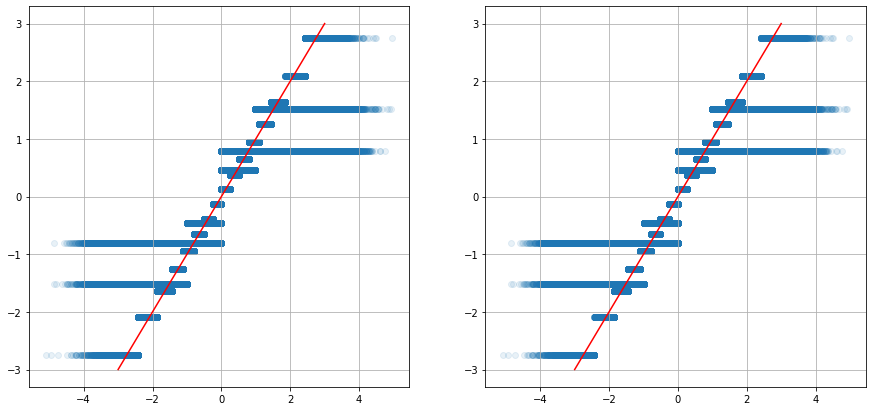

In [3]:
# test quantizer models (the numpy version)

plt.figure(figsize=(15,7))
# fit the quantizer
a=np.random.normal(0,1,(2048,2048))
q=quantizer_mixed() # also try _1b _2b _4b
q.fit(a)

# quantize, decode, visualize
ind=q.quantize(a)
a_new=q.decode(ind)
plt.subplot(1,2,1)
plt.scatter(a,a_new,alpha=0.1)
plt.plot([-3,3],[-3,3],'r')
plt.grid()

# quantize, compress, decompress, decode, visualize
data=q.quantize_compress(a)
a_new=q.load_decode(data)
plt.subplot(1,2,2)
plt.scatter(a,a_new,alpha=0.1)
plt.plot([-3,3],[-3,3],'r')
plt.grid()

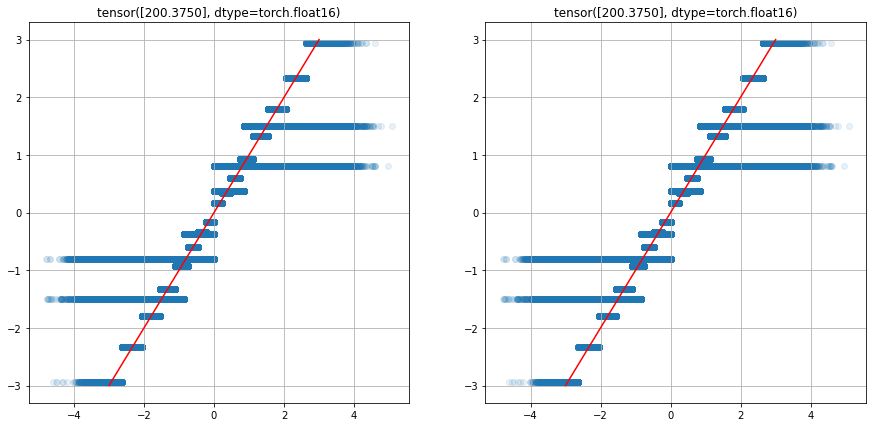

In [4]:
# test quantizer models (torch)
inp=torch.tensor(np.random.normal(0,1,(2048,2048))).to('cuda:1').to(torch.float16)

q4t=quantizer_mixed_torch(2048)
x=q4t.quantize(inp)
y=q4t.decode(x)

plt.figure(figsize=(15,7))
plt.subplot(1,2,1)

plt.scatter( inp.cpu().numpy(),y.cpu().numpy().reshape(-1),alpha=0.1)
plt.plot([-3,3],[-3,3],'r')
plt.title( torch.mean((inp-y)**2).cpu().reshape(-1)*1000 )
plt.grid()

data=q4t.quantize_compress(inp)
y=q4t.load_decode(data)

plt.subplot(1,2,2)
plt.scatter( inp.cpu().numpy(),y.cpu().numpy().reshape(-1),alpha=0.1)
plt.plot([-3,3],[-3,3],'r')
plt.title( torch.mean((inp-y)**2).cpu().reshape(-1)*1000 )
plt.grid()


In [5]:
# load data
a=np.fromfile('a_big',dtype=np.float16).reshape(-1,2048)
a=torch.tensor(a).to('cuda:2') # pass to gpu

In [4]:
W = representation_whitening_torch()


In [5]:
W.load_state_dict('wtorch.pth')

In [7]:
W.mn = W.mn.cpu()
W.q = W.q.cpu()
W.s = W.s.cpu()

In [8]:
W.save_state_dict('wtorch.pth')

: 

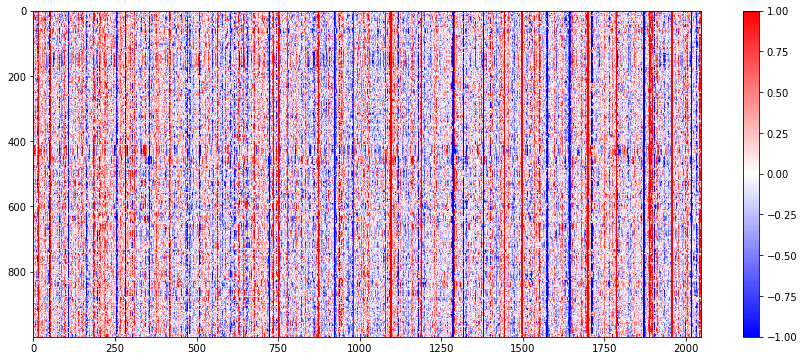

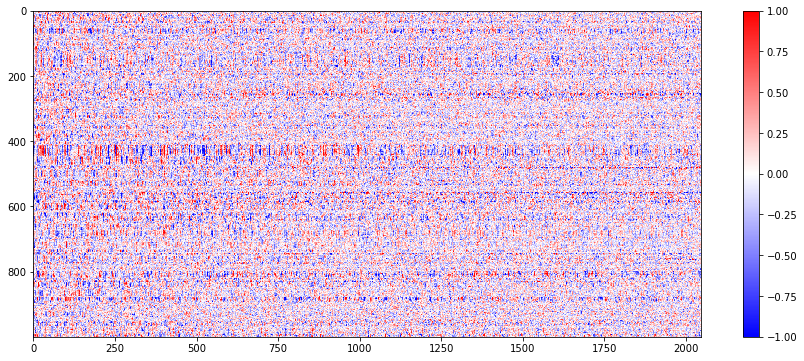

In [11]:
# test whitening

#train and save whitening
W.fit(a)
W.save_state_dict('whitening_params.pth')

#load and use whitening
W=representation_whitening_torch()
W.load_state_dict('whitening_params.pth')
aw=W.encode(a)

plt.figure(figsize=(15,6))
plt.imshow( a [0:1000,:].cpu().numpy() ,cmap='bwr',vmin=-1,vmax=1)
plt.colorbar()
plt.figure(figsize=(15,6))
plt.imshow( aw[0:1000,:].cpu().numpy() ,cmap='bwr',vmin=-1,vmax=1) #aw_new[0:4000,:]-
plt.colorbar()


In [7]:
# try the quantizer
q=quantizer_mixed_torch(2048)
data=q.quantize_compress(aw)
aw_new=q.load_decode(data)
print(data.shape)
print(a.shape)

torch.Size([661621, 480])
torch.Size([661621, 2048])


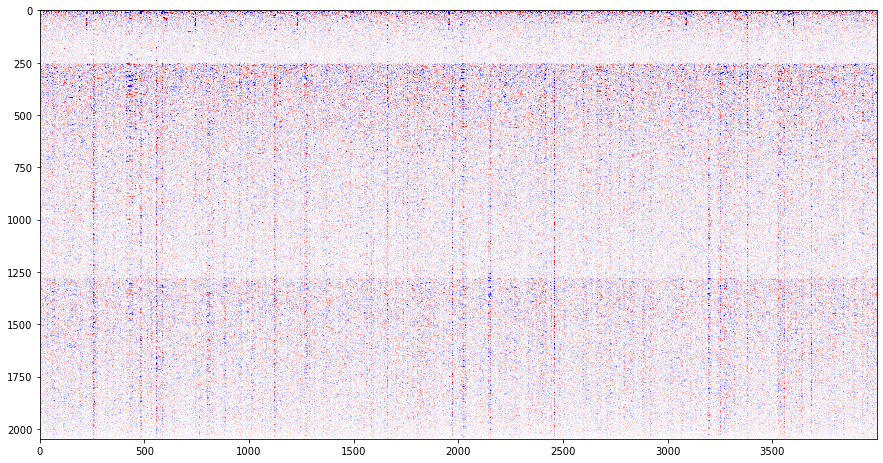

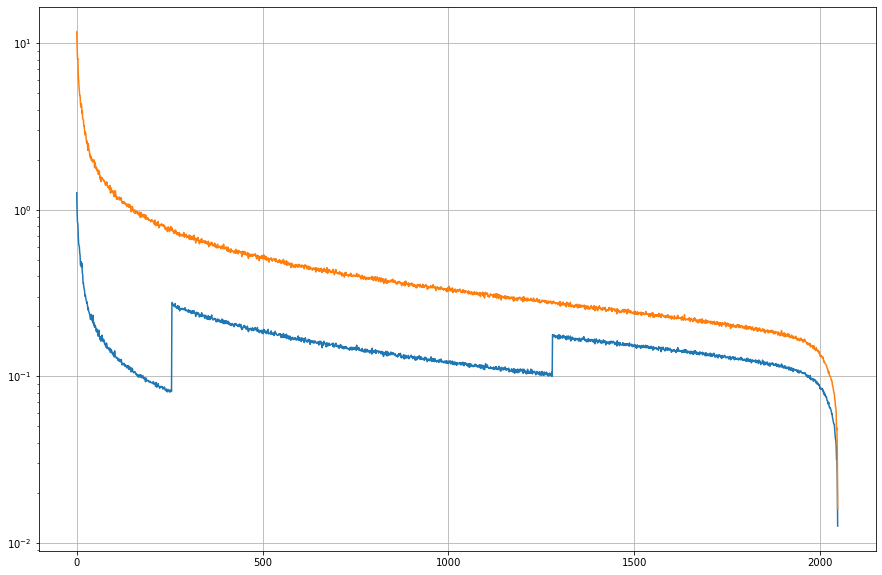

In [8]:
# visualize error
error=W.rescale(aw[0:4000,:]-aw_new[0:4000,:]).T
plt.figure(figsize=(15,15))
plt.imshow( error.cpu().numpy() ,cmap='bwr',vmin=-0.2,vmax=0.2)

plt.figure(figsize=(15,10))
plt.plot( torch.abs(error).mean(axis=1).cpu().numpy())
plt.plot( torch.abs(W.rescale(aw[0:4000,:]).T).mean(axis=1).cpu().numpy())
plt.yscale('log')
plt.grid()